In [1]:
import site

import pandas as pd
import numpy as np
import warnings

from statsmodels.sandbox.tools.cross_val import split

from utils import *


In [2]:
raw_abundances = pd.read_excel("Experiment/1_hTERT_HME1/Data/All/only_keeping_data_1_hTERT_HME1_minus10minFC.xlsx", sheet_name='raw_abundances_matrix')
normalized_abundances = pd.read_excel("Experiment/1_hTERT_HME1/Data/All/only_keeping_data_1_hTERT_HME1_minus10minFC.xlsx", sheet_name='normalized_abundances_matrix')
stats_normalized = pd.read_excel("Experiment/1_hTERT_HME1/Data/All/only_keeping_data_1_hTERT_HME1_minus10minFC.xlsx", sheet_name='stats_normalized_wide')
diff_wide = pd.read_excel("Experiment/1_hTERT_HME1/Data/All/only_keeping_data_1_hTERT_HME1_minus10minFC.xlsx", sheet_name='diff_exp_analysis_wide')
stats_raw = pd.read_excel("Experiment/1_hTERT_HME1/Data/All/only_keeping_data_1_hTERT_HME1_minus10minFC.xlsx", sheet_name='stats_raw_wide')
FC10min = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Handmade_Log2_FC_from_FGZC_only_10min.xlsx")

In [4]:
df = pd.merge(raw_abundances, normalized_abundances, on="site", how="left")
df = pd.merge(df, diff_wide, on="site", how="left")
df = pd.merge(df, stats_normalized, on="site", how="left")
df = pd.merge(df, stats_raw, on="site", how="left")
df = pd.merge(df, FC10min, on="site", how="left")

In [6]:
df.to_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1.xlsx", index=False)

In [11]:
df = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1.xlsx")

In [22]:
sub_data = df[['protein_Id', 'site', 'FC_INS2', 'FC_INS5','FC_INS10', 'FC_INS15', 'FC_INS90']].copy()
sub_data

lim = 2
for index, row in sub_data.iterrows():
    fc_list = row[['FC_INS2', 'FC_INS5','FC_INS10', 'FC_INS15', 'FC_INS90']]
    if max(fc_list) < lim and abs(min(fc_list)) < lim: #and or abs(min(fc_list)) < 2
        sub_data.drop(index, inplace=True)

sub_data

,protein_Id,site,FC_INS2,FC_INS5,FC_INS10,FC_INS15,FC_INS90
2293,O43768,O43768_108_113_1_0~KSSLVTSK,-1.762095,-0.620653,-2.179047,-0.674721,-1.261471
2678,O60343,O60343_588_591_1_1_S591~LGSVDsFER,-0.811333,-1.488621,-2.049720,-1.365674,-1.232859
3949,O75864,O75864_586_612_3_3_T588S591S597~AEPPASPtPPsPPP...,0.445746,0.167810,0.195191,0.508727,2.733359
5184,O95817,O95817_171_191_1_0~SQSPAASDCSSSSSSASLPSSGR,-2.488584,-3.042231,-2.157965,0.413885,-1.311905
6208,P08069,P08069_1161_1166_1_1_Y1161~DIyETDYYR,2.410379,2.114571,2.037120,1.491474,1.571987
6209,P08069,P08069_1161_1166_1_1_Y1165~DIYETDyYR;DIYETDyYRK,2.200209,2.021203,1.965538,1.570017,1.564087
6211,P08069,P08069_1161_1166_2_2_Y1161Y1165~DIyETDyYRK,2.166677,1.860380,1.753489,1.450034,1.169936
6215,P08069,P08069_1346_1346_1_1_Y1346~QPyAHMNGGR,2.271211,1.672627,1.309314,0.465479,0.780891
6955,P13639,P13639_57_59_2_2_T57T59~FtDtRKDEQER,-0.906279,-1.970466,-2.532255,-1.041174,-1.283935
8887,P27361,P27361_198_207_1_1_Y204~IADPEHDHTGFLTEyVATR,1.373692,2.157522,1.893259,0.472508,1.124153


In [26]:
sub_data_sites = list(sub_data["site"].unique())
proteins = [] 
for protein in sub_data_sites:
    p = protein.split("_")[0]
    proteins.append(p)
len(set(proteins))

for protein in set(proteins):
    print(protein, df.loc[df['protein_Id'] == protein, "description"].unique())

P56211 ['cAMP-regulated phosphoprotein 19 OS=Homo sapiens OX=9606 GN=ARPP19 PE=1 SV=2']
Q9H0G5 ['Nuclear speckle splicing regulatory protein 1 OS=Homo sapiens OX=9606 GN=NSRP1 PE=1 SV=1']
Q86UU1 ['Pleckstrin homology-like domain family B member 1 OS=Homo sapiens OX=9606 GN=PHLDB1 PE=1 SV=1']
Q14980 ['Nuclear mitotic apparatus protein 1 OS=Homo sapiens OX=9606 GN=NUMA1 PE=1 SV=2']
Q7LBC6 ['Lysine-specific demethylase 3B OS=Homo sapiens OX=9606 GN=KDM3B PE=1 SV=2']
Q5SW79 ['Centrosomal protein of 170 kDa OS=Homo sapiens OX=9606 GN=CEP170 PE=1 SV=1']
P08069 ['Insulin-like growth factor 1 receptor OS=Homo sapiens OX=9606 GN=IGF1R PE=1 SV=1']
Q92766 ['Ras-responsive element-binding protein 1 OS=Homo sapiens OX=9606 GN=RREB1 PE=1 SV=3']
Q8N4Q1 ['Mitochondrial intermembrane space import and assembly protein 40 OS=Homo sapiens OX=9606 GN=CHCHD4 PE=1 SV=1']
Q8WWM7 ['Ataxin-2-like protein OS=Homo sapiens OX=9606 GN=ATXN2L PE=1 SV=2']
Q7Z4S6 ['Kinesin-like protein KIF21A OS=Homo sapiens OX=9606 G

In [24]:
df_1 = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD.xlsx")

 Plot not saved


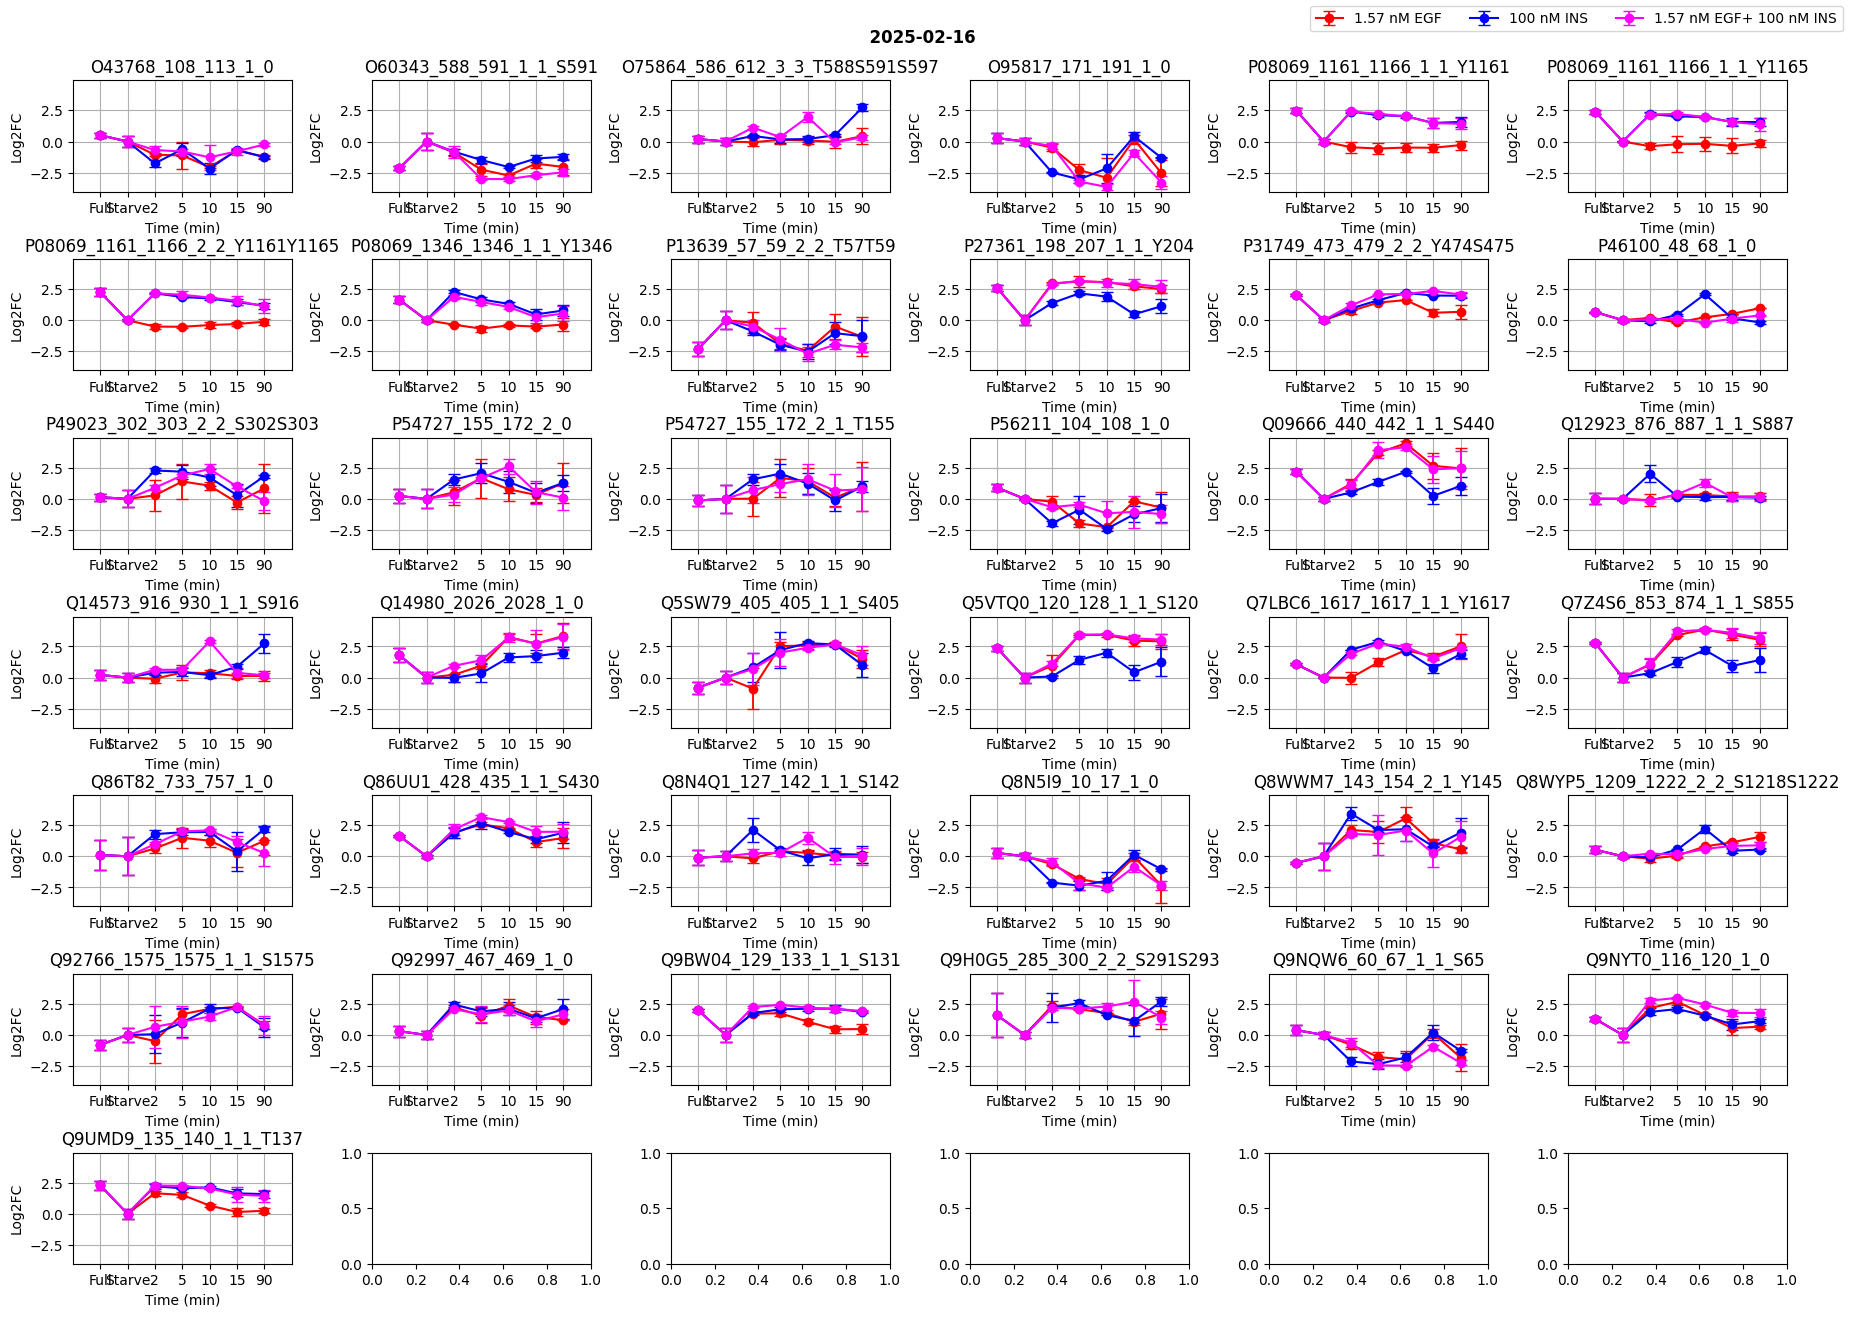

In [25]:

subset = df_1.loc[df_1['site'].isin(sub_data_sites)]

warnings.filterwarnings('ignore')

plot_dataset_phosphosites(df=subset,
                          legend = ['1.57 nM EGF', '100 nM INS', '1.57 nM EGF+ 100 nM INS'], x_axis=['Full', 'Starve', '2', '5', '10', '15', '90'], color_palette = ['r', 'b', 'fuchsia'],
                          saving_path = "", dataset_name= "", saving_info="",
                          plot_individually = False, fit_y_lims=False,  plot_close=False,
                          save_pdf=False, save_png=False)

In [3]:
print(select(options=True))
print(select(key = "log2_abundances", options = False))

dict_keys(['raw_abundances', 'log2_abundances', 'mean_raw_abundances', 'median_raw_abundances', 'CV_raw_abundances', 'mean_log2_abundances', 'median_log2_abundances', 'sd_log2_abundances', 'var_log2_abundances', 'FC', 'FC_pvalues', 'FC_FDR', 'FC_stats', 'others'])
['EGF_full_r1', 'EGF_full_r2', 'EGF_full_r3', 'EGF_full_r4', 'EGF_starve_r1', 'EGF_starve_r2', 'EGF_starve_r3', 'EGF_starve_r4', 'EGF2_r1', 'EGF2_r2', 'EGF2_r3', 'EGF2_r4', 'EGF5_r1', 'EGF5_r2', 'EGF5_r3', 'EGF5_r4', 'EGF10_r1', 'EGF10_r2', 'EGF10_r3', 'EGF10_r4', 'EGF15_r1', 'EGF15_r2', 'EGF15_r3', 'EGF15_r4', 'EGF90_r1', 'EGF90_r2', 'EGF90_r3', 'EGF90_r4', 'INS_full_r1', 'INS_full_r2', 'INS_full_r3', 'INS_full_r4', 'INS_starve_r1', 'INS_starve_r2', 'INS_starve_r3', 'INS_starve_r4', 'INS2_r1', 'INS2_r2', 'INS2_r3', 'INS2_r4', 'INS5_r1', 'INS5_r2', 'INS5_r3', 'INS5_r4', 'INS10_r1', 'INS10_r2', 'INS10_r3', 'INS10_r4', 'INS15_r1', 'INS15_r2', 'INS15_r3', 'INS15_r4', 'INS90_r1', 'INS90_r2', 'INS90_r3', 'INS90_r4', 'EGFnINS_full_